# 04 — Manual Validation Sampling: BYOND by BSI

**Tujuan:** Validasi rating filter (rating 1–2) sebagai proxy keluhan teknis.

**Metodologi:**
- Sampling: equal-allocation stratified by `relative_month` (25 × 12 = 300)
- Estimator: weighted proportion (Cochran, 1977)
- Klasifikasi: 5 kategori (4 dari Maalej et al., 2016 + 1 ekstensi domain banking)
- Threshold validitas: >70% kategori teknis (Bug Report + Feature Request + User Experience)

**Output:** `data/validation/byond_validation_sample.csv` siap upload ke Google Sheets untuk labeling manual.

**Referensi:**
- Maalej, W., Kurtanović, Z., Nabil, H., & Stanik, C. (2016). On the automatic classification of app reviews. *Requirements Engineering*, 21(3), 311–331.
- Cochran, W.G. (1977). *Sampling Techniques*, 3rd ed. Wiley.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

# Add project root to sys.path so we can import from utils/
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.validation import (
    stratified_sample_by_month,
    prepare_for_sheets,
    ALL_CATEGORIES,
    TECHNICAL_CATEGORIES,
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

print(f"pandas version: {pd.__version__}")
print(f"numpy version:  {np.__version__}")
print(f"Project root:   {project_root}")
print(f"Categories:     {ALL_CATEGORIES}")

pandas version: 3.0.2
numpy version:  2.4.4
Project root:   C:\Users\Rabithah Zahiratus S\TA
Categories:     ['Bug Report', 'Feature Request', 'User Experience', 'Rating (Praise/Dispraise)', 'Non-Technical Complaint']


## 1. Load Data BYOND

Load output dari preprocessing pipeline (`byond_bertopic.csv`). Ini sudah:
- Difilter rating 1–2 (proxy keluhan)
- Memiliki kolom `relative_month` (1–12 dari launch byond: 9 November 2024 – 8 November 2025)
- Sudah di-preprocess (text cleaning, normalization)

In [2]:
# Load byond filtered data
DATA_PATH = project_root / "data" / "processed" / "byond_bertopic.csv"
df_byond = pd.read_csv(DATA_PATH)

print(f"Shape: {df_byond.shape}")
print(f"Columns: {list(df_byond.columns)}")
print(f"\nDtypes:")
print(df_byond.dtypes)
print(f"\nFirst 3 rows:")
df_byond.head(3)

Shape: (19393, 6)
Columns: ['review_id', 'review_text_cleaned', 'relative_month', 'relative_week', 'date_wib', 'rating']

Dtypes:
review_id                str
review_text_cleaned      str
relative_month         int64
relative_week          int64
date_wib                 str
rating                 int64
dtype: object

First 3 rows:


,review_id,review_text_cleaned,relative_month,relative_week,date_wib,rating
0,2c29f9a1-67dc-4013-9e6c-8654fc55400f,masukkan data sudah benar tapi dianggap salah,1,1,2024-11-09 03:27:30,1
1,cbb3030c-ae6c-4618-ae19-89691803eb40,ini kenapa aplikasi force close terus tiba,1,1,2024-11-09 03:34:29,1
2,be2133d7-23be-4623-9292-1cd732dc2aae,belum bisa masuk selalu dikatakan data diri tidak sesuai padahal tidak ada kesalahan,1,1,2024-11-09 04:52:16,1


## 2. Verifikasi Distribusi Populasi per Relative Month

Sebelum sampling, cek distribusi populasi:
- Pastikan setiap bulan (1–12) punya cukup data (minimum 25 untuk equal stratified n=25)
- Identify bulan yang dominan vs minoritas (untuk konteks weighted estimator nanti)

Total populasi (rating 1-2): 19,393
Jumlah strata (relative_month): 12
Min populasi per bulan: 487 (bulan 1)
Max populasi per bulan: 6284 (bulan 4)

Distribusi lengkap:
                count    pct
relative_month              
1                 487   2.51
2                2040  10.52
3                1962  10.12
4                6284  32.40
5                 921   4.75
6                 543   2.80
7                1108   5.71
8                 881   4.54
9                1125   5.80
10               2552  13.16
11                807   4.16
12                683   3.52

✅ Semua bulan punya ≥25 data. Sampling tanpa replacement feasible.


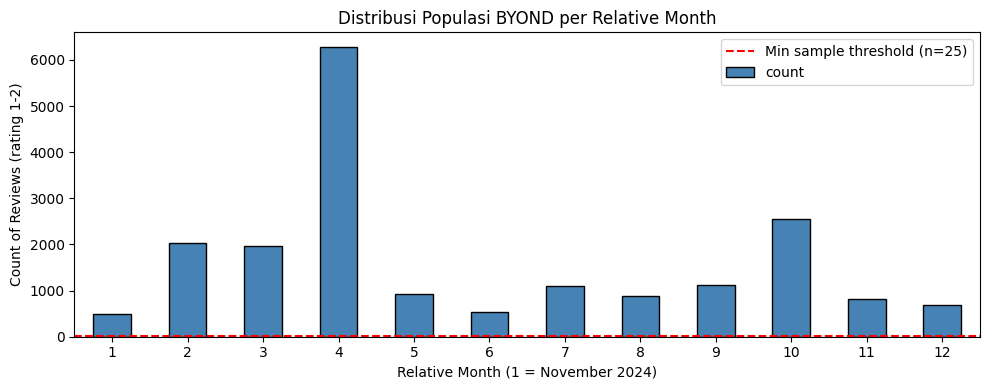

In [3]:
# Distribusi populasi per relative_month
pop_dist = df_byond.groupby("relative_month").size().rename("count")
pop_pct = (pop_dist / pop_dist.sum() * 100).round(2).rename("pct")
pop_summary = pd.concat([pop_dist, pop_pct], axis=1)

print(f"Total populasi (rating 1-2): {len(df_byond):,}")
print(f"Jumlah strata (relative_month): {df_byond['relative_month'].nunique()}")
print(f"Min populasi per bulan: {pop_dist.min()} (bulan {pop_dist.idxmin()})")
print(f"Max populasi per bulan: {pop_dist.max()} (bulan {pop_dist.idxmax()})")
print(f"\nDistribusi lengkap:")
print(pop_summary.to_string())

# Pre-flight check: cukup data untuk n=25 per stratum?
N_PER_STRATUM = 25
insufficient = pop_dist[pop_dist < N_PER_STRATUM]
if len(insufficient) > 0:
    print(f"\n⚠️ WARNING: Bulan berikut punya <{N_PER_STRATUM} data, tidak bisa di-sample tanpa replacement:")
    print(insufficient.to_string())
else:
    print(f"\n✅ Semua bulan punya ≥{N_PER_STRATUM} data. Sampling tanpa replacement feasible.")

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 4))
pop_dist.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.axhline(y=N_PER_STRATUM, color="red", linestyle="--", label=f"Min sample threshold (n={N_PER_STRATUM})")
ax.set_xlabel("Relative Month (1 = November 2024)")
ax.set_ylabel("Count of Reviews (rating 1-2)")
ax.set_title("Distribusi Populasi BYOND per Relative Month")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Test Sampling Function (Sample Kecil)

Sebelum generate full sample 300, test dulu dengan `n_per_stratum=2` (= 24 sample total) untuk:
- Verify function jalan tanpa error
- Confirm output shape & shuffling behavior
- Inspect contoh row biar tau apa yang akan kita label nanti

**Working convention:** Test small first, scale up after.

In [4]:
# Test dengan sample kecil dulu (2 per bulan = 24 sample)
test_sample = stratified_sample_by_month(
    df_byond,
    n_per_stratum=2,
    random_state=42,
)

print(f"Test sample shape: {test_sample.shape}")
print(f"Distribusi per bulan:")
print(test_sample.groupby("relative_month").size().to_string())
print(f"\nBulan urutan first 10 rows (verify shuffled, bukan urut M1-M12):")
print(test_sample["relative_month"].head(10).tolist())
print(f"\nNo duplicates: {test_sample['review_id'].is_unique}")
print(f"\nFirst 5 rows (preview):")
test_sample.head(5)

Test sample shape: (24, 6)
Distribusi per bulan:
relative_month
1     2
2     2
3     2
4     2
5     2
6     2
7     2
8     2
9     2
10    2
11    2
12    2

Bulan urutan first 10 rows (verify shuffled, bukan urut M1-M12):
[5, 9, 1, 10, 6, 5, 7, 1, 11, 3]

No duplicates: True

First 5 rows (preview):


,review_id,review_text_cleaned,relative_month,relative_week,date_wib,rating
0,c5d90c67-bf37-427e-bab4-9e2fc6bacbca,ini kenapa fitur dana enggak ada,5,19,2025-03-18 08:17:05,1
1,929a4083-b2b3-4aaf-ba0c-99174dfeb315,enggak diaplikasi enggak di mesin atm nya pelayananya payah tarik di atm nya keterangan gagal tapi saldo berkurang sudah komplen sama petugasnya t...,9,39,2025-08-07 22:29:25,1
2,69f9b512-1369-426b-8dc8-a1fe177792bf,verifikasi wajah jelimet dan sering gangguan saat registrasi,1,2,2024-11-17 14:55:53,1
3,e31de468-b255-44bb-b8dc-2b191853082c,apa ini sudah berapa hari cuma ubah data doang acc nya lama amat sudah tahu perlu bintang lah lama bener buat acc ubah data saja,10,40,2025-08-11 22:04:42,1
4,4215bbc3-11af-4538-9576-f5f5bccf42c5,menu break tabungan autosave di byond dimana mana ya di arahin ke pojok kanan atas tapi menu penutupan tidak ada tuh di aplikasi lama ada tapi mau...,6,26,2025-05-05 15:50:13,2


## 4. Generate Full Sample (n=25 per Bulan, 300 Total)

Setelah test pass, generate sample finali untuk labeling.
- `n_per_stratum=25` × 12 bulan = **300 sample**
- `random_state=42` untuk reproducibility
- Shuffled untuk hindari calibration drift saat manual labeling

In [5]:
# Generate sample final
sample_byond = stratified_sample_by_month(
    df_byond,
    n_per_stratum=25,
    random_state=42,
)

print(f"Full sample shape: {sample_byond.shape}")
print(f"Distribusi per bulan:")
print(sample_byond.groupby("relative_month").size().to_string())
print(f"\nFirst 10 months in shuffled order:")
print(sample_byond["relative_month"].head(10).tolist())
print(f"\nDistribusi rating dalam sample:")
print(sample_byond["rating"].value_counts().to_string())

Full sample shape: (300, 6)
Distribusi per bulan:
relative_month
1     25
2     25
3     25
4     25
5     25
6     25
7     25
8     25
9     25
10    25
11    25
12    25

First 10 months in shuffled order:
[9, 11, 7, 1, 10, 10, 8, 5, 1, 8]

Distribusi rating dalam sample:
rating
1    245
2     55


In [6]:
# Comprehensive sanity checks sebelum save
assert sample_byond.shape[0] == 300, f"Expected 300 rows, got {sample_byond.shape[0]}"
assert sample_byond["review_id"].is_unique, "Duplicate review_ids detected!"
assert sample_byond["rating"].isin([1, 2]).all(), "Rating outside [1, 2] detected!"
assert sample_byond.groupby("relative_month").size().eq(25).all(), "Stratum size != 25 detected!"
assert sample_byond["review_text_cleaned"].notna().all(), "Missing review text detected!"

print("✅ All sanity checks passed:")
print(f"   - Shape: 300 rows ✓")
print(f"   - All review_ids unique ✓")
print(f"   - All ratings in [1, 2] ✓")
print(f"   - All strata have exactly 25 samples ✓")
print(f"   - No missing review text ✓")

# Statistical summary
print(f"\nReview text length statistics (chars):")
text_len = sample_byond["review_text_cleaned"].str.len()
print(text_len.describe().to_string())

✅ All sanity checks passed:
   - Shape: 300 rows ✓
   - All review_ids unique ✓
   - All ratings in [1, 2] ✓
   - All strata have exactly 25 samples ✓
   - No missing review text ✓

Review text length statistics (chars):
count    300.000000
mean     130.016667
std       97.925487
min       26.000000
25%       59.750000
50%       93.000000
75%      177.000000
max      515.000000


## 5. Prepare for Sheets & Save CSV

Format sample untuk upload Google Sheets:
- Reorder kolom: labeler-facing first (`relative_month`, `rating`, `review_text_cleaned`)
- Append 2 kolom kosong: `category` (untuk dropdown) dan `notes` (untuk edge case)
- Save ke `data/validation/byond_validation_sample.csv`

**Note:** Folder `data/validation/` di-gitignore (sama seperti `data/processed/`). 
Hasil labeling nanti harus di-backup manual ke Google Drive.

In [7]:
# Prepare format untuk Sheets
# Note: text_col override karena kolom kita 'review_text_cleaned' bukan default 'review_text'
sheets_ready = prepare_for_sheets(
    sample_byond,
    text_col="review_text_cleaned",
)

print(f"Shape: {sheets_ready.shape}")
print(f"Column order: {list(sheets_ready.columns)}")
print(f"\nFirst 3 rows preview:")
sheets_ready.head(3)

Shape: (300, 8)
Column order: ['relative_month', 'rating', 'review_text_cleaned', 'category', 'notes', 'review_id', 'relative_week', 'date_wib']

First 3 rows preview:


,relative_month,rating,review_text_cleaned,category,notes,review_id,relative_week,date_wib
0,9,1,kenapa sih ini aplikasi barusan saya beli pulsa pulsa tidak masuk tapi saldo berkurang bagaimana ini admin tolong kembalikan uang saya atau kirimk...,,,7f45de29-4b3b-4af1-8aee-48b97ed0f885,36,2025-07-16 03:57:48
1,11,2,seminggu kok trobel dan sekarang pun trobel lagi kapan benernya ini aplikasi,,,af5f3868-0eaf-4b15-8f75-346bc34441bd,46,2025-09-23 23:34:30
2,7,1,bagaimana nih habis update terbaru nih malah ngebug kedip kedip tidak bisa masuk,,,77a4b37b-f38b-4f0a-8d1a-0026e224fcf2,27,2025-05-13 02:47:52


In [8]:
# Save ke data/validation/byond_validation_sample.csv
OUTPUT_DIR = project_root / "data" / "validation"
OUTPUT_DIR.mkdir(exist_ok=True)  # Defensive: create folder kalau belum ada
OUTPUT_PATH = OUTPUT_DIR / "byond_validation_sample.csv"

sheets_ready.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",  # BOM for Google Sheets/Excel UTF-8 compatibility
)

# Verify file ditulis benar
import os
file_size_kb = os.path.getsize(OUTPUT_PATH) / 1024
print(f"✅ File saved: {OUTPUT_PATH}")
print(f"   Size: {file_size_kb:.1f} KB")
print(f"   Rows: {len(sheets_ready)} + 1 header")

# Re-load untuk verify integritas
df_check = pd.read_csv(OUTPUT_PATH)
print(f"\nReload check:")
print(f"   Shape: {df_check.shape}")
print(f"   Columns: {list(df_check.columns)}")
print(f"   category empty: {df_check['category'].isna().all()}")
print(f"   notes empty: {df_check['notes'].isna().all()}")

✅ File saved: C:\Users\Rabithah Zahiratus S\TA\data\validation\byond_validation_sample.csv
   Size: 58.1 KB
   Rows: 300 + 1 header

Reload check:
   Shape: (300, 8)
   Columns: ['relative_month', 'rating', 'review_text_cleaned', 'category', 'notes', 'review_id', 'relative_week', 'date_wib']
   category empty: True
   notes empty: True


## 6. Next Steps

### Phase A (notebook ini) — DONE ✅
- ~~Generate stratified sample 300 byond~~
- ~~Save ke `data/validation/byond_validation_sample.csv`~~

### Phase B (workflow manual labeling)

1. Upload `byond_validation_sample.csv` ke Google Drive
2. Open with Google Sheets
3. Set data validation di kolom `category` (Data → Data validation):
   - Bug Report
   - Feature Request
   - User Experience
   - Rating (Praise/Dispraise)
   - Non-Technical Complaint
4. Freeze header row (View → Freeze → 1 row)
5. **Calibration phase:** Label 50 review pertama pelan-pelan untuk kalibrasi judgment
6. **Full labeling:** ~2 jam total, split jadi 2 sesi
7. Download as CSV → save ke `data/validation/byond_validation_labeled.csv`
8. **BACKUP** labeled CSV ke folder Drive lain (gak overwrite source)

### Phase C (notebook ini, section selanjutnya)

Setelah selesai labeling, kembali ke notebook ini, tambah section baru:
- Load labeled CSV
- Run `validation_summary(labeled_df, df_byond)`
- Generate tabel & visualisasi untuk Bab IV

---

## 7. Analisis Hasil Labeling (Phase C)

Phase C: Load labeled CSV, hitung weighted proportion (Cochran 1977), 
generate summary untuk Bab IV.

**Input:** `data/validation/wondr_validation_labeled.csv` (300 review labeled)
**Output:**
- Distribusi per kategori (raw count + weighted proportion)
- Validity rate keseluruhan (Bug + FR + UX = ?)
- Per-month validity rate (stabilitas temporal)
- Visualisasi untuk Bab IV

In [9]:
# Import function dari utils
from utils.validation import (
    validation_summary,
    compute_weighted_proportion,
    ALL_CATEGORIES,
    TECHNICAL_CATEGORIES,
)

# Load labeled CSV
LABELED_PATH = project_root / "data" / "validation" / "byond_validation_labeled.csv"
df_labeled = pd.read_csv(LABELED_PATH)

print(f"Shape: {df_labeled.shape}")
print(f"Columns: {list(df_labeled.columns)}")

# Sanity checks
print(f"\n=== SANITY CHECKS ===")
print(f"Total rows: {len(df_labeled)}")
print(f"Missing category labels: {df_labeled['category'].isna().sum()}")
print(f"Empty string category: {(df_labeled['category'] == '').sum()}")

# Distribusi kategori
print(f"\nDistribusi label kategori:")
print(df_labeled['category'].value_counts(dropna=False).to_string())

# Verify semua kategori valid (match konstanta di utils)
labeled_cats = set(df_labeled['category'].dropna().unique())
expected_cats = set(ALL_CATEGORIES)
unexpected = labeled_cats - expected_cats
missing = expected_cats - labeled_cats

print(f"\n=== KATEGORI VALIDATION ===")
if unexpected:
    print(f"⚠️ Unexpected categories (typo?): {unexpected}")
else:
    print(f"✅ Semua label valid (match 5 kategori expected)")
if missing:
    print(f"ℹ️ Missing categories (none labeled): {missing}")

Shape: (300, 8)
Columns: ['relative_month', 'rating', 'review_text_cleaned', 'category', 'notes', 'review_id', 'relative_week', 'date_wib']

=== SANITY CHECKS ===
Total rows: 300
Missing category labels: 0
Empty string category: 0

Distribusi label kategori:
category
Bug Report                   207
User Experience               56
Feature Request               16
Rating (Praise/Dispraise)     12
Non-Technical Complaint        9

=== KATEGORI VALIDATION ===
✅ Semua label valid (match 5 kategori expected)


In [10]:
# Generate full validation summary (raw + weighted + per-month)
summary = validation_summary(df_labeled, df_byond)

print("=" * 60)
print("VALIDATION SUMMARY: BYOND by BSI")
print("=" * 60)
print(f"\nSample total: {summary['sample_total']}")
print(f"Population total: {summary['population_total']:,}")

print(f"\n--- PER-CATEGORY BREAKDOWN ---")
print(summary['per_category'].round(2).to_string())

print(f"\n--- OVERALL VALIDITY ---")
raw_technical = (df_labeled['category'].isin(TECHNICAL_CATEGORIES)).sum()
print(f"Raw validity (sample):     {raw_technical/300*100:.2f}%")
print(f"Weighted validity (pop):   {summary['overall_validity_pct']:.2f}%")

print(f"\n--- PER-MONTH VALIDITY (% kategori teknis) ---")
print(summary['per_month_validity_pct'].round(2).to_string())

print(f"\nMin per-month validity: {summary['per_month_validity_pct'].min():.2f}% (bulan {summary['per_month_validity_pct'].idxmin()})")
print(f"Max per-month validity: {summary['per_month_validity_pct'].max():.2f}% (bulan {summary['per_month_validity_pct'].idxmax()})")
print(f"Range: {summary['per_month_validity_pct'].max() - summary['per_month_validity_pct'].min():.2f}%")

VALIDATION SUMMARY: BYOND by BSI

Sample total: 300
Population total: 19,393

--- PER-CATEGORY BREAKDOWN ---
                           raw_count  raw_pct  weighted_pct  is_technical
category                                                                 
Bug Report                       207    69.00         70.21          True
User Experience                   56    18.67         17.78          True
Feature Request                   16     5.33          2.86          True
Rating (Praise/Dispraise)         12     4.00          6.11         False
Non-Technical Complaint            9     3.00          3.03         False

--- OVERALL VALIDITY ---
Raw validity (sample):     93.00%
Weighted validity (pop):   90.85%

--- PER-MONTH VALIDITY (% kategori teknis) ---
relative_month
1     100.0
2      88.0
3      96.0
4      88.0
5     100.0
6      96.0
7      84.0
8      96.0
9     100.0
10     88.0
11     84.0
12     96.0

Min per-month validity: 84.00% (bulan 7)
Max per-month validity: 100.00

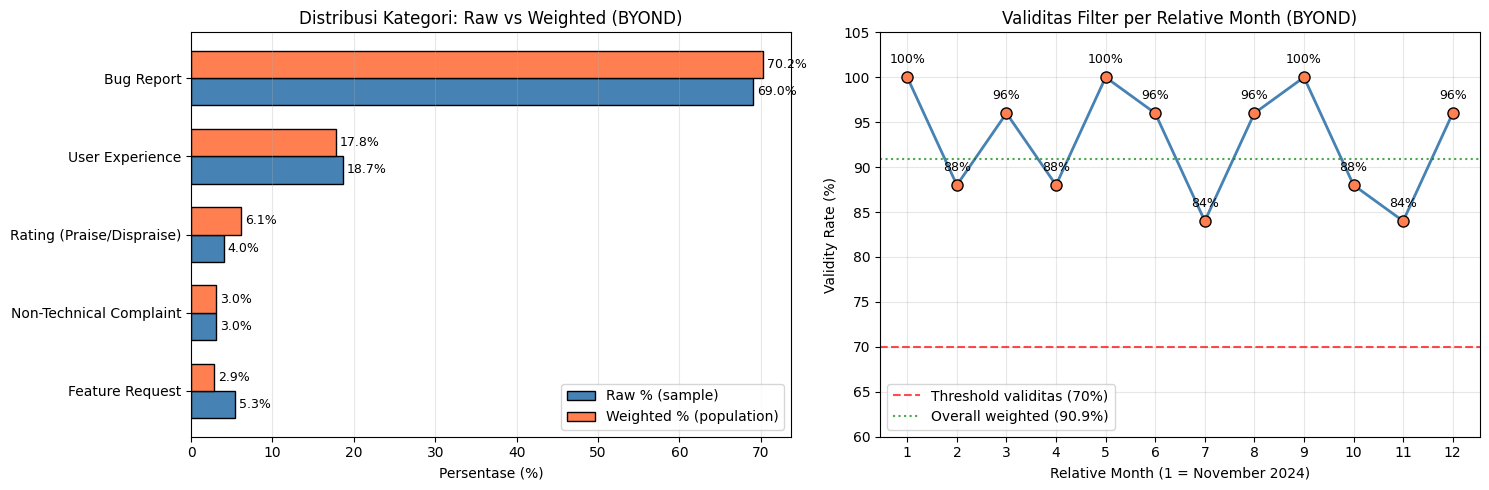

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart 1: Distribusi kategori (raw vs weighted)
cat_data = summary['per_category'].copy()
cat_data = cat_data.sort_values('weighted_pct', ascending=True)

x = np.arange(len(cat_data))
width = 0.35

bars1 = axes[0].barh(x - width/2, cat_data['raw_pct'], width,
                      label='Raw % (sample)', color='steelblue', edgecolor='black')
bars2 = axes[0].barh(x + width/2, cat_data['weighted_pct'], width,
                      label='Weighted % (population)', color='coral', edgecolor='black')

axes[0].set_yticks(x)
axes[0].set_yticklabels(cat_data.index)
axes[0].set_xlabel('Persentase (%)')
axes[0].set_title('Distribusi Kategori: Raw vs Weighted (BYOND)')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

for i, (raw, weighted) in enumerate(zip(cat_data['raw_pct'], cat_data['weighted_pct'])):
    axes[0].text(raw + 0.5, i - width/2, f'{raw:.1f}%', va='center', fontsize=9)
    axes[0].text(weighted + 0.5, i + width/2, f'{weighted:.1f}%', va='center', fontsize=9)

# Chart 2: Per-month validity
per_month = summary['per_month_validity_pct']
axes[1].plot(per_month.index, per_month.values, marker='o', linewidth=2,
             color='steelblue', markersize=8, markerfacecolor='coral', markeredgecolor='black')
axes[1].axhline(y=70, color='red', linestyle='--', label='Threshold validitas (70%)', alpha=0.7)
axes[1].axhline(y=summary['overall_validity_pct'], color='green', linestyle=':',
                label=f'Overall weighted ({summary["overall_validity_pct"]:.1f}%)', alpha=0.7)

for x_val, y_val in per_month.items():
    axes[1].annotate(f'{y_val:.0f}%', (x_val, y_val), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=9)

axes[1].set_xlabel('Relative Month (1 = November 2024)')
axes[1].set_ylabel('Validity Rate (%)')
axes[1].set_title('Validitas Filter per Relative Month (BYOND)')
axes[1].set_xticks(range(1, 13))
axes[1].set_ylim(60, 105)
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

✅ Saved: C:\Users\Rabithah Zahiratus S\TA\outputs\figures\byond_validation_summary.png


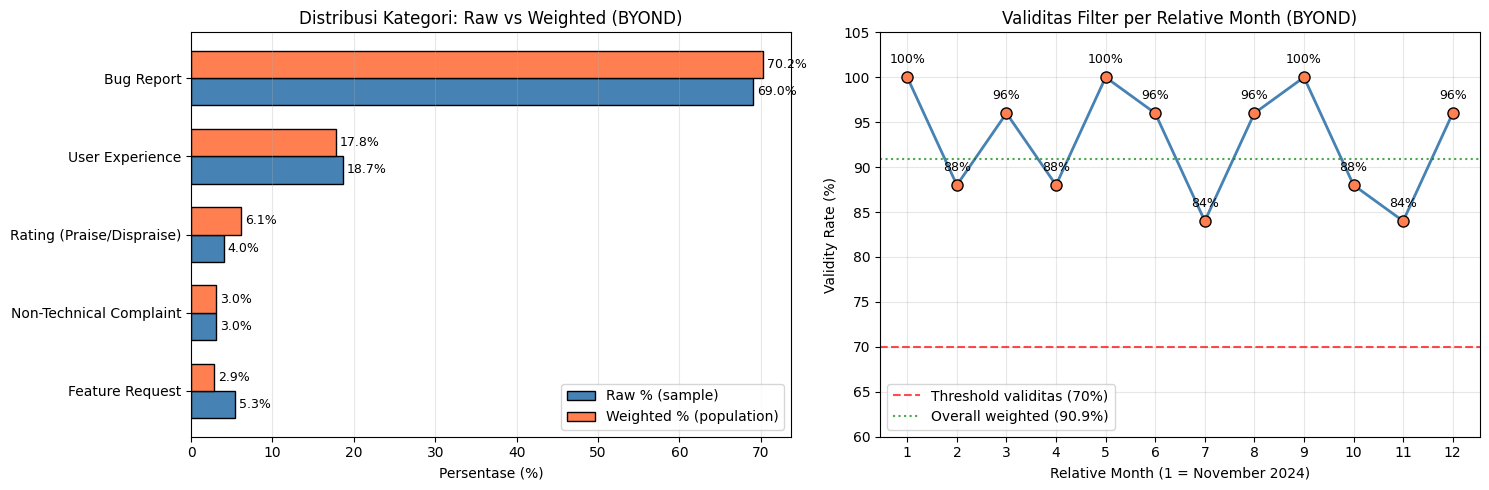

In [13]:
# Re-create chart untuk save dengan dpi tinggi
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cat_data = summary['per_category'].copy().sort_values('weighted_pct', ascending=True)
x = np.arange(len(cat_data))
width = 0.35

bars1 = axes[0].barh(x - width/2, cat_data['raw_pct'], width,
                      label='Raw % (sample)', color='steelblue', edgecolor='black')
bars2 = axes[0].barh(x + width/2, cat_data['weighted_pct'], width,
                      label='Weighted % (population)', color='coral', edgecolor='black')

axes[0].set_yticks(x)
axes[0].set_yticklabels(cat_data.index)
axes[0].set_xlabel('Persentase (%)')
axes[0].set_title('Distribusi Kategori: Raw vs Weighted (BYOND)')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

for i, (raw, weighted) in enumerate(zip(cat_data['raw_pct'], cat_data['weighted_pct'])):
    axes[0].text(raw + 0.5, i - width/2, f'{raw:.1f}%', va='center', fontsize=9)
    axes[0].text(weighted + 0.5, i + width/2, f'{weighted:.1f}%', va='center', fontsize=9)

per_month = summary['per_month_validity_pct']
axes[1].plot(per_month.index, per_month.values, marker='o', linewidth=2,
             color='steelblue', markersize=8, markerfacecolor='coral', markeredgecolor='black')
axes[1].axhline(y=70, color='red', linestyle='--', label='Threshold validitas (70%)', alpha=0.7)
axes[1].axhline(y=summary['overall_validity_pct'], color='green', linestyle=':',
                label=f'Overall weighted ({summary["overall_validity_pct"]:.1f}%)', alpha=0.7)

for x_val, y_val in per_month.items():
    axes[1].annotate(f'{y_val:.0f}%', (x_val, y_val), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=9)

axes[1].set_xlabel('Relative Month (1 = November 2024)')
axes[1].set_ylabel('Validity Rate (%)')
axes[1].set_title('Validitas Filter per Relative Month (BYOND)')
axes[1].set_xticks(range(1, 13))
axes[1].set_ylim(60, 105)
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()

OUTPUT_FIG_DIR = project_root / "outputs" / "figures"
OUTPUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

fig_path = OUTPUT_FIG_DIR / "byond_validation_summary.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✅ Saved: {fig_path}")

plt.show()

In [14]:
OUTPUT_TABLE_DIR = project_root / "outputs" / "tables"
OUTPUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Tabel 1: Per-category breakdown
table1 = summary['per_category'].copy()
table1['raw_count'] = table1['raw_count'].astype(int)
table1[['raw_pct', 'weighted_pct']] = table1[['raw_pct', 'weighted_pct']].round(2)
table1_path = OUTPUT_TABLE_DIR / "byond_validation_per_category.csv"
table1.to_csv(table1_path, encoding='utf-8-sig')
print(f"✅ Tabel 1 saved: {table1_path}")
print(table1.to_string())

# Tabel 2: Per-month validity
table2 = pd.DataFrame({
    'relative_month': summary['per_month_validity_pct'].index,
    'validity_pct': summary['per_month_validity_pct'].round(2).values,
    'population_count': df_byond.groupby('relative_month').size().values,
    'sample_count': df_labeled.groupby('relative_month').size().values,
})
table2_path = OUTPUT_TABLE_DIR / "byond_validation_per_month.csv"
table2.to_csv(table2_path, index=False, encoding='utf-8-sig')
print(f"\n✅ Tabel 2 saved: {table2_path}")
print(table2.to_string(index=False))

# Tabel 3: Headline metrics
raw_technical = (df_labeled['category'].isin(TECHNICAL_CATEGORIES)).sum()
table3 = pd.DataFrame({
    'metric': [
        'Total Population',
        'Sample Size',
        'Strata (relative months)',
        'Sample per Stratum',
        'Raw Validity %',
        'Weighted Validity % (Cochran 1977)',
        'Min Per-Month Validity %',
        'Max Per-Month Validity %',
        'Range Per-Month Validity %',
    ],
    'value': [
        summary['population_total'],
        summary['sample_total'],
        12,
        25,
        round(raw_technical/300*100, 2),
        round(summary['overall_validity_pct'], 2),
        round(summary['per_month_validity_pct'].min(), 2),
        round(summary['per_month_validity_pct'].max(), 2),
        round(summary['per_month_validity_pct'].max() - summary['per_month_validity_pct'].min(), 2),
    ]
})
table3_path = OUTPUT_TABLE_DIR / "byond_validation_headline.csv"
table3.to_csv(table3_path, index=False, encoding='utf-8-sig')
print(f"\n✅ Tabel 3 saved: {table3_path}")
print(table3.to_string(index=False))

✅ Tabel 1 saved: C:\Users\Rabithah Zahiratus S\TA\outputs\tables\byond_validation_per_category.csv
                           raw_count  raw_pct  weighted_pct  is_technical
category                                                                 
Bug Report                       207    69.00         70.21          True
User Experience                   56    18.67         17.78          True
Feature Request                   16     5.33          2.86          True
Rating (Praise/Dispraise)         12     4.00          6.11         False
Non-Technical Complaint            9     3.00          3.03         False

✅ Tabel 2 saved: C:\Users\Rabithah Zahiratus S\TA\outputs\tables\byond_validation_per_month.csv
 relative_month  validity_pct  population_count  sample_count
              1         100.0               487            25
              2          88.0              2040            25
              3          96.0              1962            25
              4          88.0         